# Stage 4: Model-Centric Improvement — EfficientNet-B0 전이학습

**목적:** Stage 3과 동일한 데이터 파이프라인을 유지하면서 EfficientNet-B0 전이학습 모델을 적용하여
모델 아키텍처 자체의 기여를 순수하게 분리 측정한다.

**핵심 설계 원칙:**
- Stage 3과 **완전히 동일한 데이터 파이프라인** — CLAHE + 레터박스 + 동일 증강
- **ImageNet 사전학습 가중치** 활용 (mean=[0.485, 0.456, 0.406] 정규화)
- **2단계 파인튜닝**: Phase 1 (classifier만, 5 epoch) → Phase 2 (전체 레이어, 이후)
- **Grad-CAM** 시각화로 모델 attention 분석 (TP vs FN 비교)

| 항목 | 내용 |
|---|---|
| 모델 | EfficientNet-B0 (pretrained ImageNet) |
| 파인튜닝 | Phase1: classifier only (lr=0.001, 5 epoch) → Phase2: full (lr=0.0001) |
| 증강 | Stage 3 동일: CLAHE + 레터박스 + HorizontalFlip + BrightnessContrast |
| 정규화 | ImageNet 통계 (mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]) |
| Grad-CAM target | `model.features[7][-1]` (16×16 feature map) |

## 0. 환경 설정

In [1]:
import sys
import os

# 프로젝트 루트를 sys.path에 추가 (notebooks/ 하위에서 실행 시)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import json
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cv2
from pathlib import Path

print(f"Python     : {sys.version.split()[0]}")
print(f"PyTorch    : {torch.__version__}")
print(f"CUDA 가용  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU        : {torch.cuda.get_device_name(0)}")
    print(f"VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: CUDA 사용 불가 — CPU로 실행됩니다.")
print(f"Project root: {PROJECT_ROOT}")

Python     : 3.10.12
PyTorch    : 2.5.1+cu121
CUDA 가용  : True
GPU        : NVIDIA GeForce RTX 3060
VRAM       : 12.9 GB
Project root: /home/jinxin4u/dl/bin/projects/kolektorsdd-classification


## 1. Config 로드

In [2]:
from src.utils.config import load_config, resolve_normalization
from omegaconf import OmegaConf

# cwd를 프로젝트 루트로 맞춰야 상대 경로가 올바르게 동작한다
os.chdir(PROJECT_ROOT)

cfg = load_config(
    base_path="configs/base.yaml",
    experiment_path="configs/experiment_model_centric.yaml",
)
resolve_normalization(cfg)

# ImageNet 정규화 값이 올바르게 설정되었는지 검증
assert list(cfg.augmentation.train.normalize_mean) == [0.485, 0.456, 0.406], (
    f"normalize_mean 오류: {cfg.augmentation.train.normalize_mean} (ImageNet 값이어야 함)"
)
print("normalize_mean 검증 통과 — ImageNet 값 사용 확인")

print("\n[Config 요약]")
print(f"  stage             : {cfg.stage}")
print(f"  model             : {cfg.model.architecture}")
print(f"  pretrained        : {cfg.model.pretrained}")
print(f"  freeze_backbone   : {cfg.model.freeze_backbone}")
print(f"  frozen_epochs     : {cfg.training.frozen_epochs}")
print(f"  Phase1 lr         : {cfg.training.lr}")
print(f"  Phase2 lr         : {cfg.training.phase2_lr}")
print(f"  epochs            : {cfg.training.epochs}")
print(f"  early_stop_patience: {cfg.training.early_stopping_patience}")
print(f"  batch_size        : {cfg.training.batch_size}")
print(f"  normalize_mean    : {list(cfg.augmentation.train.normalize_mean)}")
print(f"  normalize_std     : {list(cfg.augmentation.train.normalize_std)}")
print(f"  loss.type         : {cfg.loss.type}")

normalize_mean 검증 통과 — ImageNet 값 사용 확인

[Config 요약]
  stage             : 4
  model             : efficientnet_b0
  pretrained        : True
  freeze_backbone   : True
  frozen_epochs     : 5
  Phase1 lr         : 0.001
  Phase2 lr         : 0.0001
  epochs            : 30
  early_stop_patience: 10
  batch_size        : 32
  normalize_mean    : [0.485, 0.456, 0.406]
  normalize_std     : [0.229, 0.224, 0.225]
  loss.type         : bce_with_logits


## 2. Dataset / DataLoader 구성

**Stage 4 데이터 파이프라인 — Stage 3와 동일:**
- `cfg.augmentation.train.letterbox = true` → 레터박스 리사이즈 파이프라인 활성화
- CLAHE (clip_limit=2.0, p=0.5) — 그레이스케일 대비 향상
- HorizontalFlip (p=0.5) + RandomBrightnessContrast (p=0.4)
- 정규화: ImageNet mean/std (Stage 3의 dataset 통계 대신 ImageNet 사용)

In [3]:
from src.data.dataset import build_dataloaders

train_loader, val_loader, test_loader = build_dataloaders(cfg)

print("[DataLoader 구성 완료]")
print(f"  Train : {len(train_loader.dataset):4d} 샘플 "
      f"({sum(1 for _, l in train_loader.dataset if l == 1)} defect / "
      f"{sum(1 for _, l in train_loader.dataset if l == 0)} normal)")
print(f"  Val   : {len(val_loader.dataset):4d} 샘플 "
      f"({sum(1 for _, l in val_loader.dataset if l == 1)} defect / "
      f"{sum(1 for _, l in val_loader.dataset if l == 0)} normal)")
print(f"  Test  : {len(test_loader.dataset):4d} 샘플 "
      f"({sum(1 for _, l in test_loader.dataset if l == 1)} defect / "
      f"{sum(1 for _, l in test_loader.dataset if l == 0)} normal)")

# 배치 shape 확인
sample_imgs, sample_labels = next(iter(train_loader))
print(f"\n배치 shape   : {sample_imgs.shape}  (B, C, H, W)")
print(f"레이블 shape : {sample_labels.shape}")
print(f"픽셀 min/max : {sample_imgs.min():.3f} / {sample_imgs.max():.3f}")

/home/jinxin4u/dl/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


[DataLoader 구성 완료]
  Train :  280 샘플 (36 defect / 244 normal)
  Val   :   56 샘플 (7 defect / 49 normal)
  Test  :   63 샘플 (9 defect / 54 normal)

배치 shape   : torch.Size([32, 3, 256, 256])  (B, C, H, W)
레이블 shape : torch.Size([32])
픽셀 min/max : -2.118 / 2.640


## 3. 모델 구성 — EfficientNet-B0

In [4]:
from src.models.transfer import build_transfer_model

model = build_transfer_model(cfg)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print("[EfficientNet-B0 파라미터 현황 — Phase 1 (Backbone Frozen)]")
print(f"  전체      : {total_params:,} ({total_params / 1e6:.2f}M)")
print(f"  학습 가능 : {trainable_params:,} ({trainable_params / 1e6:.2f}M)")
print(f"  고정 (frozen): {frozen_params:,} ({frozen_params / 1e6:.2f}M)")
print(f"  학습 비율 : {trainable_params / total_params * 100:.1f}%")

# Dummy forward pass로 출력 shape 검증
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
dummy_input = torch.randn(4, 3, 224, 224).to(device)
with torch.no_grad():
    dummy_out = model(dummy_input)
print(f"\nDummy forward: input {tuple(dummy_input.shape)} -> output {tuple(dummy_out.shape)}")
assert dummy_out.shape == (4, 1), f"출력 shape 오류: {dummy_out.shape} (기대: (4, 1))"
print("출력 shape 검증 통과 (B, 1) — BCEWithLogitsLoss 호환")

[EfficientNet-B0 파라미터 현황 — Phase 1 (Backbone Frozen)]
  전체      : 4,008,829 (4.01M)
  학습 가능 : 1,281 (0.00M)
  고정 (frozen): 4,007,548 (4.01M)
  학습 비율 : 0.0%

Dummy forward: input (4, 3, 224, 224) -> output (4, 1)
출력 shape 검증 통과 (B, 1) — BCEWithLogitsLoss 호환


## 4. 학습 실행

**2단계 파인튜닝 전략:**
- **Phase 1** (epoch 1~5): Backbone frozen, classifier head만 학습 (lr=0.001)
  - 랜덤 초기화된 head가 올바른 방향으로 수렴할 때까지 backbone을 보호
- **Phase 2** (epoch 6~): Backbone 전체 학습 재개 (lr=0.0001)
  - 낮은 lr로 pretrained feature를 세밀하게 조정 (catastrophic forgetting 방지)

In [5]:
from src.training.trainer import Trainer

# 새 모델 인스턴스 생성 (GPU로 이동은 Trainer 내부에서 처리)
model = build_transfer_model(cfg)

trainer = Trainer(model, cfg)
train_results = trainer.fit(train_loader, val_loader)

print(f"\n학습 완료")
print(f"  Best val F1 : {train_results['best_val_f1']:.4f}")
print(f"  Best epoch  : {train_results['best_epoch']}")

2026-03-31 18:07:10 | INFO     | src.training.trainer | pos_weight 자동 계산: 244/36 = 6.7778
2026-03-31 18:07:10 | INFO     | src.training.trainer | 손실 함수: BCEWithLogitsLoss (pos_weight=6.7778)
2026-03-31 18:07:10 | INFO     | src.training.trainer | 학습 시작 — device=cuda, epochs=30, patience=10
2026-03-31 18:07:10 | INFO     | src.training.trainer | Phase 1: epoch 1~5 — classifier only (lr=0.001)
2026-03-31 18:07:15 | INFO     | src.training.trainer | Epoch   1/30 | train_loss=1.2487 | val_loss=1.1584 | val_F1=0.2500 | val_AUC=0.8280
2026-03-31 18:07:15 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.2500)
2026-03-31 18:07:19 | INFO     | src.training.trainer | Epoch   2/30 | train_loss=1.2049 | val_loss=1.1727 | val_F1=0.2222 | val_AUC=0.5889
2026-03-31 18:07:22 | INFO     | src.training.trainer | Epoch   3/30 | train_loss=1.2177 | val_loss=1.1817 | val_F1=0.2222 | val_AUC=0.5423
2026-03-31 18:07:24 | INFO     | src.training.trainer | Epoch   4/30 | train_loss=1.2409 | val

## 5. 학습 곡선 시각화

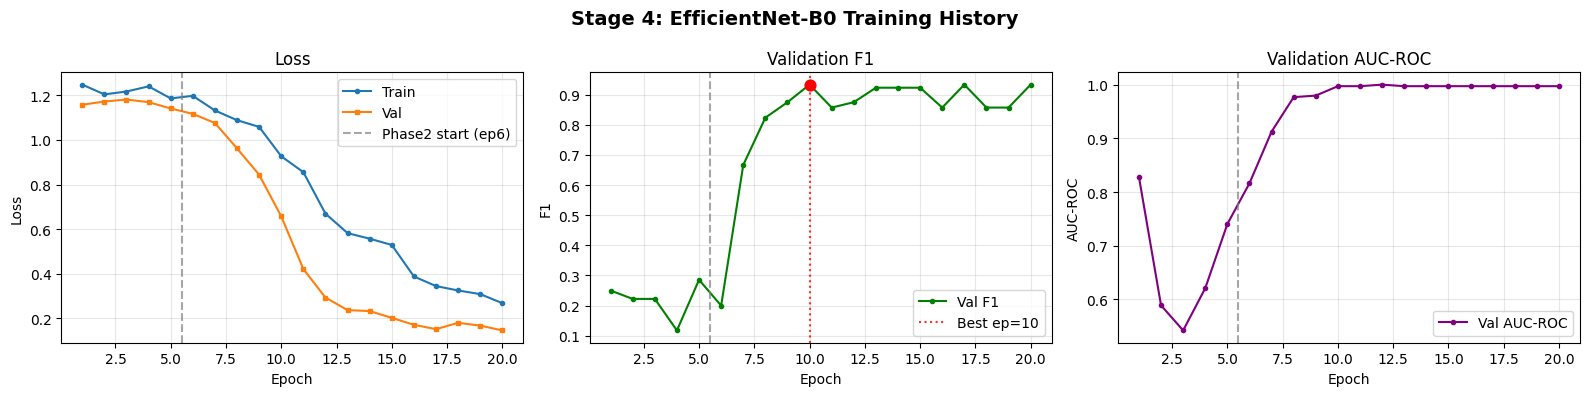

저장 완료: experiments/model_centric/figures/training_history.png


In [6]:
history_df = pd.DataFrame(train_results["history"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Stage 4: EfficientNet-B0 Training History", fontsize=14, fontweight="bold")

# Phase 전환 지점
frozen_ep = cfg.training.frozen_epochs

# Loss
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train", marker="o", markersize=3)
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Val", marker="s", markersize=3)
axes[0].axvline(x=frozen_ep + 0.5, color="gray", linestyle="--", alpha=0.7, label=f"Phase2 start (ep{frozen_ep+1})")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1
axes[1].plot(history_df["epoch"], history_df["val_f1"], label="Val F1", color="green", marker="o", markersize=3)
best_ep = train_results["best_epoch"]
best_f1 = history_df.loc[history_df["epoch"] == best_ep, "val_f1"].values
if len(best_f1) > 0:
    axes[1].axvline(x=best_ep, color="red", linestyle=":", alpha=0.8, label=f"Best ep={best_ep}")
    axes[1].scatter([best_ep], best_f1, color="red", zorder=5, s=60)
axes[1].axvline(x=frozen_ep + 0.5, color="gray", linestyle="--", alpha=0.7)
axes[1].set_title("Validation F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# AUC-ROC
axes[2].plot(history_df["epoch"], history_df["val_auc_roc"], label="Val AUC-ROC", color="purple", marker="o", markersize=3)
axes[2].axvline(x=frozen_ep + 0.5, color="gray", linestyle="--", alpha=0.7)
axes[2].set_title("Validation AUC-ROC")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("AUC-ROC")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

fig_dir = Path("experiments/model_centric/figures")
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / "training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"저장 완료: {fig_dir / 'training_history.png'}")

## 6. 검증 / 테스트 평가 및 결과 저장

In [7]:
# 검증 셋 평가
val_metrics = trainer.evaluate(val_loader, split_name="val")
print("\n[Validation Metrics]")
for k, v in val_metrics.items():
    if isinstance(v, float):
        print(f"  {k:20s}: {v:.4f}")
    else:
        print(f"  {k:20s}: {v}")

# 테스트 셋 평가
test_metrics = trainer.evaluate(test_loader, split_name="test")
print("\n[Test Metrics]")
for k, v in test_metrics.items():
    if isinstance(v, float):
        print(f"  {k:20s}: {v:.4f}")
    else:
        print(f"  {k:20s}: {v}")

# 결과 저장
trainer.save_results(
    val_metrics=val_metrics,
    test_metrics=test_metrics,
    output_path="experiments/model_centric/results.json",
)
print("\nresults.json 저장 완료: experiments/model_centric/results.json")

/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:296: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-03-31 18:08:36 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=10)
2026-03-31 18:08:37 | INFO     | src.training.trainer | [val] F1=0.9333 | AUC=0.9971 | Precision=0.8750 | Recall=1.0000

[Validation Metrics]
  f1                  : 0.9333
  auc_roc             : 0.9971
  precision           : 0.8750
  recall              : 1.0000
  average_precision   : 0.9821
  confusion_matrix    : [[48, 1], [0, 7]]
  threshold           : 0.5000


/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:296: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-03-31 18:08:39 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=10)
2026-03-31 18:08:40 | INFO     | src.training.trainer | [test] F1=0.8235 | AUC=0.9568 | Precision=0.8750 | Recall=0.7778

[Test Metrics]
  f1                  : 0.8235
  auc_roc             : 0.9568
  precision           : 0.8750
  recall              : 0.7778
  average_precision   : 0.8898
  confusion_matrix    : [[53, 1], [2, 7]]
  threshold           : 0.5000
2026-03-31 18:08:40 | INFO     | src.training.trainer | 결과 저장 완료: experiments/model_centric/results.json

results.json 저장 완료: experiments/model_centric/results.json


## 7. Confusion Matrix + ROC/PR 커브

임계값: 0.5
테스트 샘플: 63 (defect=9, normal=54)


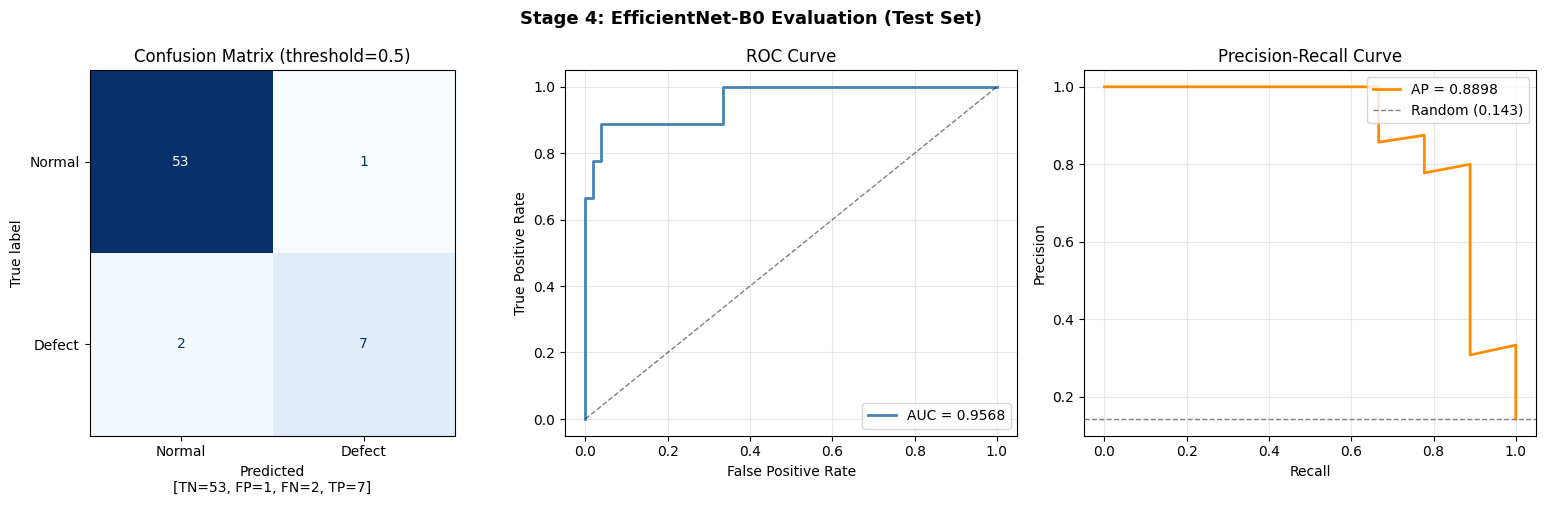

저장 완료: experiments/model_centric/figures/evaluation_curves.png


In [8]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
)

# 테스트 셋 예측값 수집
device_eval = trainer.device
trainer.model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.float().to(device_eval)
        logits = trainer.model(imgs)
        probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()
        all_probs.extend(probs.tolist())
        all_labels.extend(lbls.numpy().tolist())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
threshold = cfg.evaluation.threshold
all_preds = (all_probs >= threshold).astype(int)

print(f"임계값: {threshold}")
print(f"테스트 샘플: {len(all_labels)} (defect={all_labels.sum():.0f}, normal={(all_labels==0).sum():.0f})")

# --- 시각화 ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Stage 4: EfficientNet-B0 Evaluation (Test Set)", fontsize=13, fontweight="bold")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Defect"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix (threshold={threshold})")
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(f"Predicted\n[TN={tn}, FP={fp}, FN={fn}, TP={tp}]")

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

# PR Curve
precision_curve, recall_curve, _ = precision_recall_curve(all_labels, all_probs)
ap = average_precision_score(all_labels, all_probs)
baseline_precision = all_labels.mean()
axes[2].plot(recall_curve, precision_curve, color="darkorange", lw=2, label=f"AP = {ap:.4f}")
axes[2].axhline(y=baseline_precision, color="gray", linestyle="--", lw=1, label=f"Random ({baseline_precision:.3f})")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")
axes[2].legend(loc="upper right")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(fig_dir / "evaluation_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"저장 완료: {fig_dir / 'evaluation_curves.png'}")

## 8. 모델 비교: BaselineCNN + 데이터 증강 vs EfficientNet-B0 전이학습 + 데이터 증강

In [9]:
# Stage 3 Data-Centric [ BaselineCNN + 데이터 증강 ] 결과 로드
with open("experiments/data_centric/results.json", "r") as f:
    s3_results = json.load(f)

# Stage 4 Model Centric [ EfficientNet-B0 + 데이터 증강 ] 결과 로드
with open("experiments/model_centric/results.json", "r") as f:
    s4_results = json.load(f)

s3_val  = s3_results["metrics"]["val"]
s4_val  = s4_results["metrics"]["val"]
s3_test = s3_results["metrics"]["test"]
s4_test = s4_results["metrics"]["test"]

metrics_keys = ["f1", "auc_roc", "average_precision", "precision", "recall"]

# Val 비교 테이블
rows_val = []
for k in metrics_keys:
    s3_v = s3_val.get(k, float("nan"))
    s4_v = s4_val.get(k, float("nan"))
    delta = s4_v - s3_v if (not (s3_v != s3_v) and not (s4_v != s4_v)) else float("nan")
    rows_val.append({"Metric": k, "BaselineCNN+Aug (Val)": s3_v, "EfficientNet-B0+Aug (Val)": s4_v, "Delta": delta})

# Test 비교 테이블
rows_test = []
for k in metrics_keys:
    s3_v = s3_test.get(k, float("nan"))
    s4_v = s4_test.get(k, float("nan"))
    delta = s4_v - s3_v if (not (s3_v != s3_v) and not (s4_v != s4_v)) else float("nan")
    rows_test.append({"Metric": k, "BaselineCNN+Aug (Test)": s3_v, "EfficientNet-B0+Aug (Test)": s4_v, "Delta": delta})

df_val  = pd.DataFrame(rows_val)
df_test = pd.DataFrame(rows_test)

def highlight_delta(val):
    """Delta 컬럼 — 양수: 초록 글자, 음수: 빨간 글자."""
    if isinstance(val, float) and val == val:  # not NaN
        if val > 0.001:
            return "color: #27ae60; font-weight: bold"
        elif val < -0.001:
            return "color: #e74c3c; font-weight: bold"
    return ""

print("[Validation Set 비교]")
print("=" * 60)
display(df_val.style.format("{:.4f}", subset=df_val.columns[1:]).map(highlight_delta, subset=["Delta"]))

print("\n" + "=" * 60)
print("[Test Set 비교]")
print("=" * 60)
display(df_test.style.format("{:.4f}", subset=df_test.columns[1:]).map(highlight_delta, subset=["Delta"]))


[Validation Set 비교]


,Metric,BaselineCNN+Aug (Val),EfficientNet-B0+Aug (Val),Delta
0,f1,0.2609,0.9333,0.6725
1,auc_roc,0.5539,0.9971,0.4431
2,average_precision,0.1538,0.9821,0.8283
3,precision,0.1538,0.8750,0.7212
4,recall,0.8571,1.0000,0.1429



[Test Set 비교]


,Metric,BaselineCNN+Aug (Test),EfficientNet-B0+Aug (Test),Delta
0,f1,0.2642,0.8235,0.5594
1,auc_roc,0.6008,0.9568,0.3560
2,average_precision,0.3668,0.8898,0.5230
3,precision,0.1591,0.8750,0.7159
4,recall,0.7778,0.7778,0.0000


## 9. Grad-CAM 구현 및 시각화

**Grad-CAM 원리:** 마지막 합성곱 레이어의 feature map에 대한 클래스 스코어의 기울기를
가중 평균하여 입력 이미지에서 모델이 집중하는 영역을 시각화한다.

- **target layer:** `model.features[7][-1]` — EfficientNet-B0의 마지막 MBConv 블록 출력
- **TP (True Positive):** 결함을 올바르게 감지 — 모델이 실제 결함 위치에 집중하는지 확인
- **FN (False Negative):** 결함을 놓침 — 모델이 무엇을 보고 있는지 분석

In [10]:
class GradCAM:
    """Grad-CAM 구현 — register_forward_hook + register_full_backward_hook 사용.

    Args:
        model: 평가할 PyTorch 모델
        target_layer: activation을 뽑을 레이어 (nn.Module)
    """

    def __init__(self, model: torch.nn.Module, target_layer: torch.nn.Module):
        self.model = model
        self.activations = None
        self.gradients = None

        # Forward hook: activation 저장
        self._forward_hook = target_layer.register_forward_hook(
            lambda module, inp, out: setattr(self, "activations", out.detach())
        )
        # Backward hook: gradient 저장
        self._backward_hook = target_layer.register_full_backward_hook(
            lambda module, grad_in, grad_out: setattr(self, "gradients", grad_out[0].detach())
        )

    def generate(self, input_tensor: torch.Tensor) -> np.ndarray:
        """입력 이미지에 대한 Grad-CAM heat map을 반환한다 (값 범위 [0, 1]).

        Args:
            input_tensor: (1, C, H, W) 형태의 입력 텐서

        Returns:
            cam: (H, W) 형태의 heat map (0~1 정규화)
        """
        self.model.eval()
        self.model.zero_grad()

        output = self.model(input_tensor)  # (1, 1)

        # 이진분류: 출력 스칼라에 대해 backward
        output.squeeze().backward()

        # 가중 평균: (C,) — 각 채널의 중요도
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)  # (1, C, 1, 1)

        # Weighted sum of activations
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # (1, 1, H, W)
        cam = torch.relu(cam).squeeze().cpu().numpy()                 # ReLU + (H, W)

        # 0~1 정규화
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max - cam_min > 1e-8:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = np.zeros_like(cam)

        return cam

    def remove_hooks(self):
        """등록된 hook을 모두 제거한다."""
        self._forward_hook.remove()
        self._backward_hook.remove()


def overlay_cam(image_tensor: torch.Tensor, cam: np.ndarray,
                mean: list, std: list, alpha: float = 0.5) -> np.ndarray:
    """정규화된 텐서 + CAM heat map을 오버레이하여 BGR 이미지로 반환한다."""
    # 역정규화: (C, H, W) → (H, W, C) numpy
    img = image_tensor.squeeze(0).cpu().numpy()  # (C, H, W)
    mean_arr = np.array(mean).reshape(3, 1, 1)
    std_arr = np.array(std).reshape(3, 1, 1)
    img = img * std_arr + mean_arr                # 역정규화
    img = np.clip(img, 0, 1)
    img = (img * 255).astype(np.uint8)
    img = img.transpose(1, 2, 0)                  # (H, W, C) RGB

    # CAM을 입력 크기로 resize
    H, W = img.shape[:2]
    cam_resized = cv2.resize(cam, (W, H))

    # heat map 생성 (Jet colormap)
    heatmap = cv2.applyColorMap((cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)  # → RGB

    # 오버레이
    overlay = (alpha * heatmap + (1 - alpha) * img).astype(np.uint8)
    return overlay


print("GradCAM 클래스 정의 완료")

GradCAM 클래스 정의 완료


In [11]:
# --- TP / FN 샘플 인덱스 수집 ---
trainer.model.eval()

tp_indices = []  # True Positive: label=1, pred=1
fn_indices = []  # False Negative: label=1, pred=0

all_test_imgs = []
all_test_labels_list = []
all_test_preds = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs_dev = imgs.float().to(device_eval)
        logits = trainer.model(imgs_dev)
        probs_b = torch.sigmoid(logits).squeeze(1).cpu().numpy()
        preds_b = (probs_b >= threshold).astype(int)
        all_test_imgs.append(imgs)  # CPU tensor
        all_test_labels_list.extend(lbls.numpy().tolist())
        all_test_preds.extend(preds_b.tolist())

all_test_imgs_tensor = torch.cat(all_test_imgs, dim=0)  # (N, C, H, W)
all_test_labels_arr = np.array(all_test_labels_list)
all_test_preds_arr = np.array(all_test_preds)

for i in range(len(all_test_labels_arr)):
    if all_test_labels_arr[i] == 1 and all_test_preds_arr[i] == 1:
        tp_indices.append(i)
    elif all_test_labels_arr[i] == 1 and all_test_preds_arr[i] == 0:
        fn_indices.append(i)

print(f"Test set: TP={len(tp_indices)}, FN={len(fn_indices)}")
print(f"TP 인덱스: {tp_indices}")
print(f"FN 인덱스: {fn_indices}")

Test set: TP=7, FN=2
TP 인덱스: [2, 11, 21, 29, 31, 46, 48]
FN 인덱스: [45, 59]


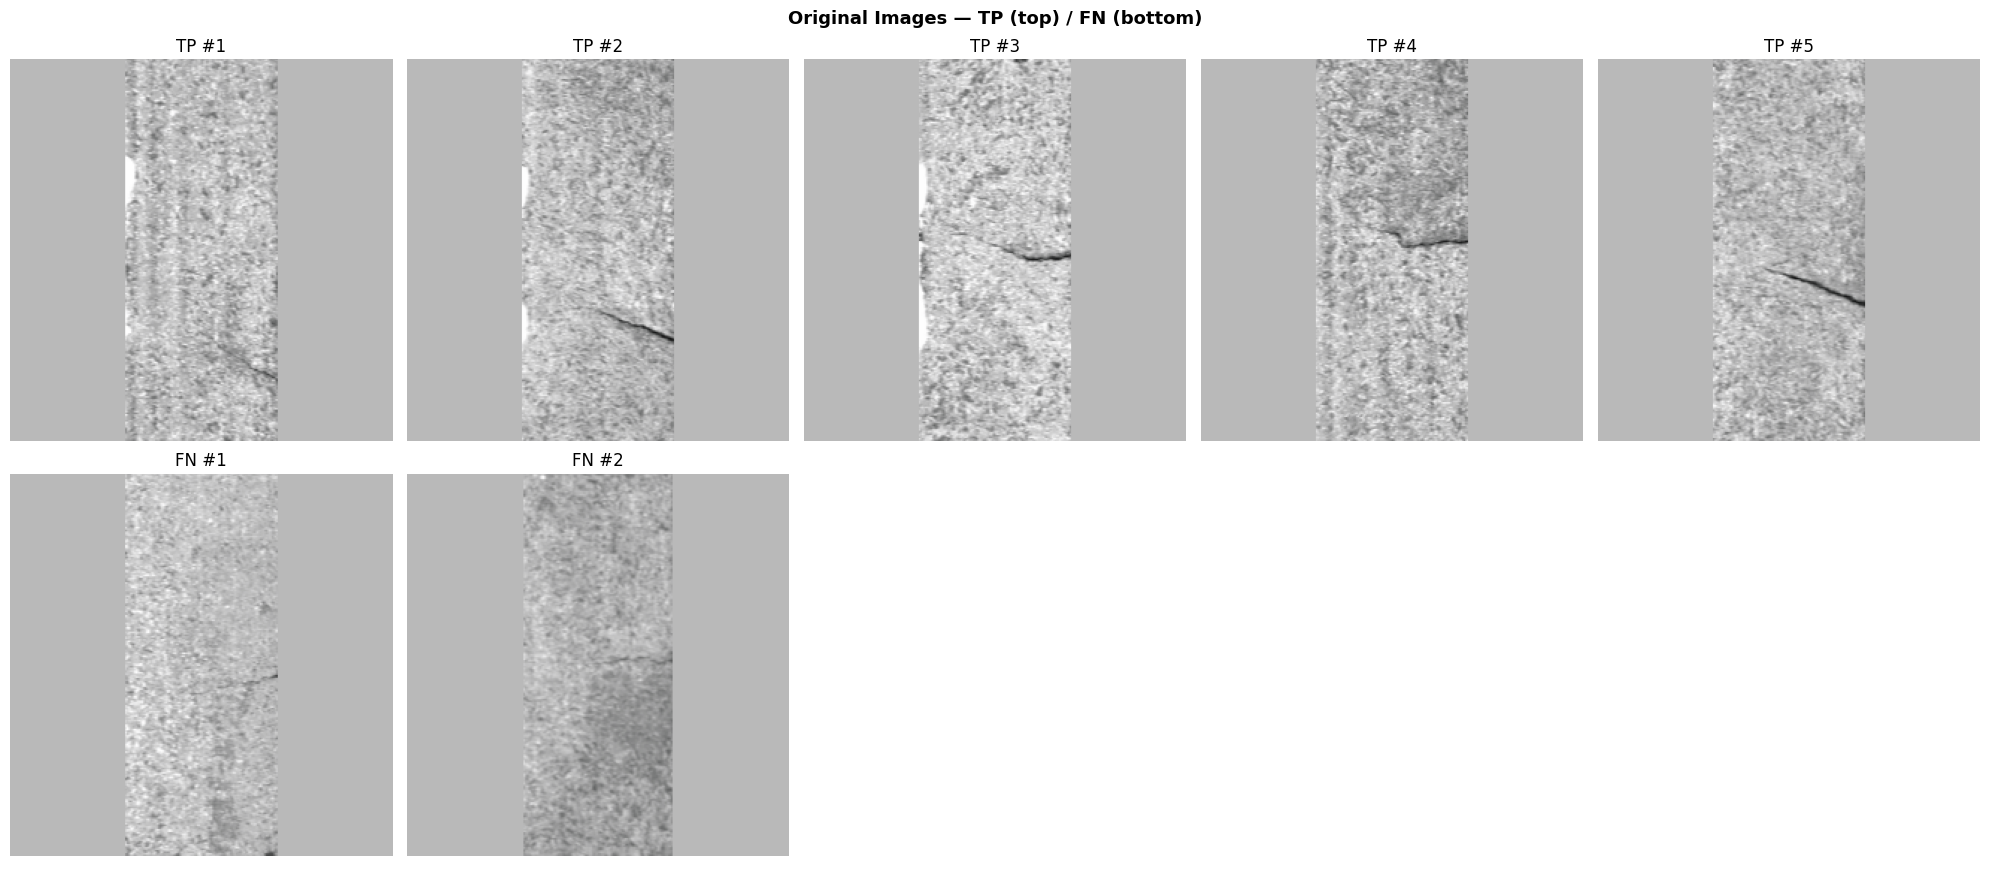

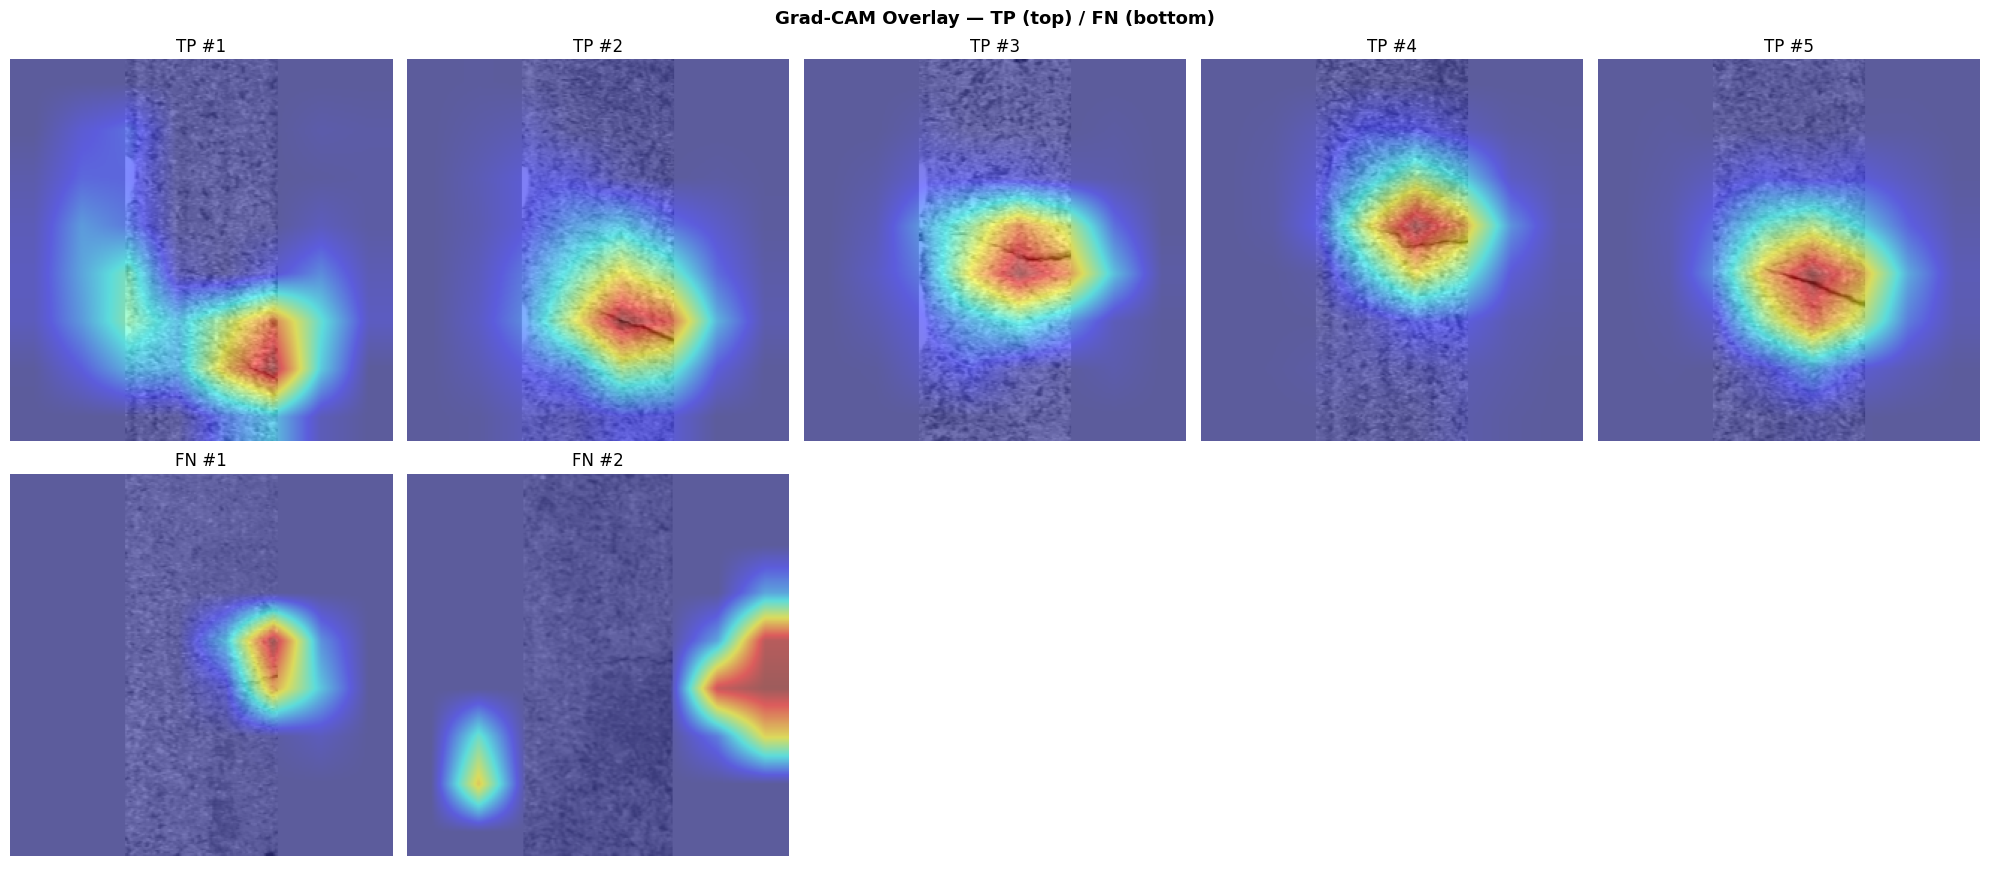

In [14]:
# --- Grad-CAM 시각화 ---
target_layer = trainer.model.features[7][-1]
gradcam = GradCAM(trainer.model, target_layer)

norm_mean = list(cfg.augmentation.val.normalize_mean)
norm_std  = list(cfg.augmentation.val.normalize_std)

MAX_SHOW = 5
tp_show = (tp_indices + [None] * MAX_SHOW)[:MAX_SHOW]
fn_show = (fn_indices + [None] * MAX_SHOW)[:MAX_SHOW]

def get_original_rgb(img_tensor):
    img = img_tensor.squeeze(0).cpu().numpy()
    mean_arr = np.array(norm_mean).reshape(3, 1, 1)
    std_arr  = np.array(norm_std).reshape(3, 1, 1)
    img = np.clip(img * std_arr + mean_arr, 0, 1)
    return (img * 255).astype(np.uint8).transpose(1, 2, 0)

# Figure 1: 원본
fig1, axes1 = plt.subplots(2, MAX_SHOW, figsize=(4 * MAX_SHOW, 9))
fig1.suptitle("Original Images — TP (top) / FN (bottom)", fontsize=13, fontweight="bold")

for col, idx in enumerate(tp_show):
    ax = axes1[0, col]
    if idx is None: ax.axis("off"); continue
    ax.imshow(get_original_rgb(all_test_imgs_tensor[idx]))
    ax.set_title(f"TP #{col+1}"); ax.axis("off")

for col, idx in enumerate(fn_show):
    ax = axes1[1, col]
    if idx is None: ax.axis("off"); continue
    ax.imshow(get_original_rgb(all_test_imgs_tensor[idx]))
    ax.set_title(f"FN #{col+1}"); ax.axis("off")

plt.tight_layout()
plt.savefig(figures_dir / "gradcam_original.png", dpi=150, bbox_inches="tight")
plt.show()

# Figure 2: Grad-CAM
fig2, axes2 = plt.subplots(2, MAX_SHOW, figsize=(4 * MAX_SHOW, 9))
fig2.suptitle("Grad-CAM Overlay — TP (top) / FN (bottom)", fontsize=13, fontweight="bold")

for col, idx in enumerate(tp_show):
    ax = axes2[0, col]
    if idx is None: ax.axis("off"); continue
    img_tensor = all_test_imgs_tensor[idx]
    cam = gradcam.generate(img_tensor.unsqueeze(0).to(trainer.device))
    ax.imshow(overlay_cam(img_tensor, cam, norm_mean, norm_std))
    ax.set_title(f"TP #{col+1}"); ax.axis("off")

for col, idx in enumerate(fn_show):
    ax = axes2[1, col]
    if idx is None: ax.axis("off"); continue
    img_tensor = all_test_imgs_tensor[idx]
    cam = gradcam.generate(img_tensor.unsqueeze(0).to(trainer.device))
    ax.imshow(overlay_cam(img_tensor, cam, norm_mean, norm_std))
    ax.set_title(f"FN #{col+1}"); ax.axis("off")

plt.tight_layout()
plt.savefig(figures_dir / "gradcam.png", dpi=150, bbox_inches="tight")
plt.show()
gradcam.remove_hooks()

## 10. FN 원인 분석

---

### 관찰 포인트 1: CAM 집중 영역

- **TP 케이스:** TP #2, #3, #5는 크랙 위치를 정확히 집중, TP #1, #4는 크랙 중심부에서 조금 벗어남 - 전반적으로 결함 영역을 탐지
- **FN 케이스:** FN #1은 이미지 전반에 관심도가 분산, FN #2는 결함 영역이 아닌 레터박스 경계에 집중
- **공통:** TP #1, FN #1의 경우 레터박스 경계에 집중하는 경향 있음

*→ TP는 전반적으로 결함 위치를 잘 잡고 있으나, FN 2건 모두 결함 영역 집중 실패*

---

### 관찰 포인트 2: 결함 미세성

- FN #1: 원본에서 결함 크기가 작아 육안으로 식별하기에도 모호함 - 배경 텍스처와 대비가 낮음
- FN #2: 결함이 희미하게 존재하다 레터박스 패딩 경계의 대비선이 결함보다 강한 신호로 작용한 것으로 판단됨(fill=186으로 설정되어 극단값 문제 아님)

*→ FN #1은 contrast(대비) 자체가 부족, FN #2는 레터박스 경계가 결함보다 강한 신호로 경쟁*

---

### 관찰 포인트 3: 잘못된 feature 학습 가능성

- 레터박스 경계에 반응하는 패턴(TP #1, FN #1, FN #2)이 복수 케이스에서 관찰되는 건, 단순 노이즈가 아닌 패딩 역역에 대한 엉뚱한 특성을 모델이 학습했을 가능성이 높음

*→ 레터박스의 fill 값을 ImageNet 평균에 가까운 값으로 재조정 시도해볼 것*

## 11. state.yaml 업데이트용 metrics 출력

In [16]:
# Stage 3 기준값 (delta 계산용)
S3_VAL_F1  = 0.2609
S3_VAL_AUC = 0.5539
S3_TEST_F1  = 0.2642
S3_TEST_AUC = 0.6008

# Stage 4 실제 metrics
s4_val_f1  = val_metrics.get("f1", float("nan"))
s4_val_auc = val_metrics.get("auc_roc", float("nan"))
s4_val_ap  = val_metrics.get("average_precision", float("nan"))
s4_test_f1  = test_metrics.get("f1", float("nan"))
s4_test_auc = test_metrics.get("auc_roc", float("nan"))
s4_test_ap  = test_metrics.get("average_precision", float("nan"))

delta_val_f1  = s4_val_f1 - S3_VAL_F1
delta_val_auc = s4_val_auc - S3_VAL_AUC
delta_test_f1  = s4_test_f1 - S3_TEST_F1
delta_test_auc = s4_test_auc - S3_TEST_AUC

yaml_output = f"""
# state.yaml에 붙여넣을 Stage 4 완료 블록
# (stages.stage4 아래에 추가)

  stage4:
    status: complete
    model: efficientnet_b0
    metrics:
      val_f1: {s4_val_f1:.4f}
      val_auc: {s4_val_auc:.4f}
      val_ap: {s4_val_ap:.4f}
      test_f1: {s4_test_f1:.4f}
      test_auc: {s4_test_auc:.4f}
      test_ap: {s4_test_ap:.4f}
    delta_vs_stage3:
      val_f1: {delta_val_f1:+.4f}
      val_auc: {delta_val_auc:+.4f}
      test_f1: {delta_test_f1:+.4f}
      test_auc: {delta_test_auc:+.4f}
"""

print(yaml_output)
print("-" * 50)
print(f"[요약]")
print(f"  Val  F1 : {S3_VAL_F1:.4f} -> {s4_val_f1:.4f}  (delta={delta_val_f1:+.4f})")
print(f"  Val  AUC: {S3_VAL_AUC:.4f} -> {s4_val_auc:.4f}  (delta={delta_val_auc:+.4f})")
print(f"  Test F1 : {S3_TEST_F1:.4f} -> {s4_test_f1:.4f}  (delta={delta_test_f1:+.4f})")
print(f"  Test AUC: {S3_TEST_AUC:.4f} -> {s4_test_auc:.4f}  (delta={delta_test_auc:+.4f})")


# state.yaml에 붙여넣을 Stage 4 완료 블록
# (stages.stage4 아래에 추가)

  stage4:
    status: complete
    model: efficientnet_b0
    metrics:
      val_f1: 0.8571
      val_auc: 0.9942
      val_ap: 0.9683
      test_f1: 0.7000
      test_auc: 0.9691
      test_ap: 0.8959
    delta_vs_stage3:
      val_f1: +0.5962
      val_auc: +0.4403
      test_f1: +0.4358
      test_auc: +0.3683

--------------------------------------------------
[요약]
  Val  F1 : 0.2609 -> 0.8571  (delta=+0.5962)
  Val  AUC: 0.5539 -> 0.9942  (delta=+0.4403)
  Test F1 : 0.2642 -> 0.7000  (delta=+0.4358)
  Test AUC: 0.6008 -> 0.9691  (delta=+0.3683)
